# Camzyos Adoption Analysis — Reproducible Technical Report

**BB Biotech Investment Case — Tasks 1 & 2**

This notebook runs the full analysis end-to-end from `synthetic_data/`. It reads as a narrative document and produces all key figures and tables. All modelling logic lives in `src/` modules; this notebook orchestrates and explains.

Full case study: [`docs/TASK_1_2_CASE_STUDY.md`](../docs/TASK_1_2_CASE_STUDY.md).

---

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer

from src.style import C_OBS, C_PRED, INK_SEC, SURFACE, style_ax

np.random.seed(42)

---

# Part 1 — Adoption Modelling

**Question:** Which patients are likely to initiate Camzyos, and when? How is uptake evolving?

## 1.1 Data and cohort definition

We load the synthetic claims data and build a person-month panel conditioned on Disopyramide experience (the near-universal precondition for Camzyos in this dataset — 98.8% of initiators have prior Disopyramide). This conditions the risk set on the common precondition and focuses the survival question on what differentiates those who switch from those who don't.

In [2]:
from src.task1_adoption.config import (
    LAUNCH_MONTH,
    MONTH_COL,
    REFINED_FEATURES,
    DatasetConfig,
    SplitConfig,
)
from src.task1_adoption.data_loading import load_data
from src.task1_adoption.dataset import build_dataset

data = load_data()
panel = build_dataset(data, DatasetConfig())

n_patients = panel["patient_id"].nunique()
n_events = int(panel["event"].sum())
print(f"Panel: {len(panel):,} person-months, {n_patients} patients, {n_events} events")
print("Risk set: Disopyramide-conditioned")
print(f"Observation window: {LAUNCH_MONTH} → end of data")

Panel: 9,256 person-months, 775 patients, 146 events
Risk set: Disopyramide-conditioned
Observation window: 2022-04 → end of data


## 1.2 Temporal train/test split

We split temporally: months 1–12 post-launch for training, months 13–21 for testing. This mimics the real forecasting task — train on the first year of adoption, predict the second. It also means the test set contains later-phase adopters whose behaviour may differ from early adopters.

In [3]:
split_cfg = SplitConfig()
split_month = (
    pd.Period(split_cfg.train_end_month, freq="M") - pd.Period(LAUNCH_MONTH, freq="M")
).n + 1

train = panel[panel[MONTH_COL] <= split_month].copy()
test = panel[panel[MONTH_COL] > split_month].copy()

print(
    f"Train: {len(train):,} person-months, {int(train['event'].sum())} events (months 1-{split_month})"
)
print(
    f"Test:  {len(test):,} person-months, {int(test['event'].sum())} events (months {split_month + 1}+)"
)

Train: 5,276 person-months, 91 events (months 1-12)
Test:  3,980 person-months, 55 events (months 13+)


## 1.3 Discrete-time hazard model

**Why this model?** Our data is monthly with heavy ties (many events share the same calendar month). Cox PH handles ties poorly at this density. Binary classification on censored data commits immortal time bias. The complementary log-log link gives us the discrete-time equivalent of proportional hazards, with calendar-month dummies absorbing baseline hazard non-parametrically.

**Feature selection:** Stability selection (Meinshausen & Bühlmann) — 200 bootstrap resamples of 70% of patients, L1-penalised logistic regression, CV-tuned regularisation. Features with selection probability ≥0.60 retained. This avoids the instability of single LASSO and the p-hacking of stepwise selection.

In [4]:
from src.task1_adoption.evaluation import bootstrap_test_ci
from src.task1_adoption.models import DiscreteHazardGLM

# Build feature matrix
refined_available = [f for f in REFINED_FEATURES if f in panel.columns]
all_cols = refined_available + [MONTH_COL]

ct = ColumnTransformer(
    [("time", "passthrough", [MONTH_COL]), ("features", "passthrough", refined_available)],
    remainder="drop",
)
X_train = pd.DataFrame(
    ct.fit_transform(train[all_cols]), columns=ct.get_feature_names_out(), index=train.index
)
X_test = pd.DataFrame(
    ct.transform(test[all_cols]), columns=ct.get_feature_names_out(), index=test.index
)

# Fit
model = DiscreteHazardGLM(link="cloglog").fit(X_train, train["event"])

# Coefficient table
coef_tbl = model.coef_table
feature_coefs = coef_tbl[~coef_tbl.index.str.startswith("time__")]
print("Refined model coefficients (4 features + intercept):")
display(feature_coefs[["coef", "HR", "HR_lower", "HR_upper", "p"]].round(3))

Refined model coefficients (4 features + intercept):


,coef,HR,HR_lower,HR_upper,p
const,-4.980,0.007,0.003,0.016,0.000
features__months_since_diso,-0.009,0.991,0.963,1.020,0.526
features__ccb_ever,1.687,5.401,2.639,11.056,0.000
features__bb_current,-1.886,0.152,0.021,1.093,0.061
features__ccb_current,-1.624,0.197,0.072,0.541,0.002


### Interpretation

The story is treatment trajectory, not severity:

- **`ccb_ever` (HR 5.40, p < 0.001):** Having ever tried a calcium channel blocker signals deeper treatment escalation — the single strongest predictor.
- **`ccb_current` (HR 0.20, p = 0.002):** Being *currently on* a CCB suppresses switching in the current month — the patient is still being managed.
- **`bb_current` (HR 0.15, p = 0.061):** Currently on a beta-blocker has the expected protective direction but is borderline significant with a wide CI.
- **`months_since_diso` (HR 0.99, p = 0.53):** Not individually significant; could be removed in future versions.

Age, sex, and symptom-burden codes (dyspnea, HF, fatigue) are **not predictive**. The clinical variables that actually drive prescribing — LVOT gradient, NYHA class — are invisible in billing data.

## 1.4 Model evaluation

Two metrics, each measuring something different:

- **Time-dependent AUC (discrimination):** can the model rank patients by initiation probability within each month?
- **Brier Skill Score (calibration):** are the predicted probabilities correct in absolute terms? This matters for market sizing — if the model says 2%/month for a cohort, we need ~2% to actually initiate.

In [5]:
test = test.copy()
test["pred"] = model.predict_proba(X_test)[:, 1]

# Bootstrap CIs (patient-level resampling, 500 iterations)
print("Bootstrapping (500 resamples)…")
ci = bootstrap_test_ci(test, n_bootstrap=500, random_state=42)
auc_pt, auc_lo, auc_hi = ci["auc"]
bss_pt, bss_lo, bss_hi = ci["bss"]
mae_pt, mae_lo, mae_hi = ci["count_mae"]

print(f"\nTime-dependent AUC: {auc_pt:.3f}  95% CI [{auc_lo:.2f}, {auc_hi:.2f}]")
print(f"Brier Skill Score:  {bss_pt:+.4f}  95% CI [{bss_lo:+.4f}, {bss_hi:+.4f}]")
print(f"Count MAE:          {mae_pt:.1f}/mo   95% CI [{mae_lo:.1f}, {mae_hi:.1f}]")

Bootstrapping (500 resamples)…



Time-dependent AUC: 0.720  95% CI [0.66, 0.77]
Brier Skill Score:  +0.0089  95% CI [+0.0040, +0.0123]
Count MAE:          1.7/mo   95% CI [1.5, 3.7]


### Calibration check

Monthly predicted vs observed new starts. If these track each other, the hazard estimates are usable in a market-sizing model without recalibration.

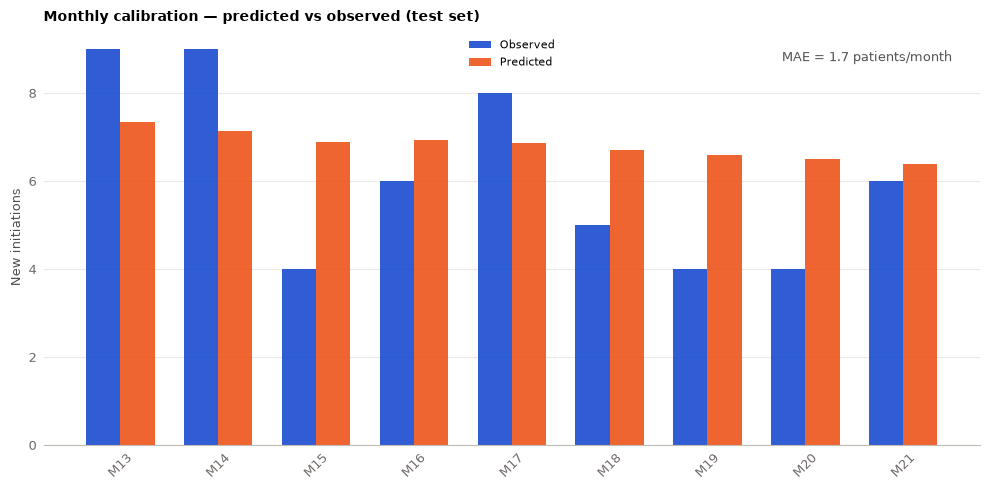

In [6]:
monthly = test.groupby(MONTH_COL).agg(obs=("event", "sum"), pred=("pred", "sum")).reset_index()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=SURFACE)
x = np.arange(len(monthly))
w = 0.35
ax.bar(x - w / 2, monthly["obs"], width=w, color=C_OBS, alpha=0.85, label="Observed")
ax.bar(x + w / 2, monthly["pred"], width=w, color=C_PRED, alpha=0.85, label="Predicted")
ax.set_xticks(x)
ax.set_xticklabels([f"M{int(m)}" for m in monthly[MONTH_COL]], rotation=45)
ax.set_ylabel("New initiations", fontsize=9, color=INK_SEC)
ax.set_title(
    "Monthly calibration — predicted vs observed (test set)",
    fontsize=10,
    fontweight="bold",
    loc="left",
)
ax.text(
    0.97,
    0.95,
    f"MAE = {mae_pt:.1f} patients/month",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=INK_SEC,
)
ax.legend(fontsize=8, frameon=False)
style_ax(ax, hide_top_right=True, grid_axis="y")
plt.tight_layout()
plt.show()

## 1.5 Patient archetypes

To make the model actionable for the IC, we construct four archetypal patient profiles and compute their predicted monthly hazard. This answers "who are the next adopters?" concretely.

In [7]:
def median_time_to_initiation(h):
    return np.log(0.5) / np.log(1 - h) if h > 0.001 else float("inf")


ref_month = split_month
ref_months_diso = float(panel.loc[panel[MONTH_COL] == ref_month, "months_since_diso"].median())

ARCHETYPES = [
    {
        "label": "Not escalated (on BB, no CCB history)",
        "ccb_ever": 0,
        "bb_current": 1,
        "ccb_current": 0,
    },
    {"label": "Currently managed (on BB + CCB)", "ccb_ever": 1, "bb_current": 1, "ccb_current": 1},
    {"label": "CCB-tried, still on BB", "ccb_ever": 1, "bb_current": 1, "ccb_current": 0},
    {
        "label": "Escalated, off meds (CCB history, off both)",
        "ccb_ever": 1,
        "bb_current": 0,
        "ccb_current": 0,
    },
]

rows = []
for arch in ARCHETYPES:
    row = pd.DataFrame(
        {
            MONTH_COL: [ref_month],
            "months_since_diso": [ref_months_diso],
            "ccb_ever": [arch["ccb_ever"]],
            "bb_current": [arch["bb_current"]],
            "ccb_current": [arch["ccb_current"]],
        }
    )
    X_arch = pd.DataFrame(
        ct.transform(row[refined_available + [MONTH_COL]]),
        columns=ct.get_feature_names_out(),
    )
    h = float(model.predict_proba(X_arch)[0, 1])
    med = median_time_to_initiation(h)
    rows.append(
        {
            "Archetype": arch["label"],
            "Hazard/month": f"{h:.1%}",
            "Median TTI": f"{med:.0f} months" if med < 9999 else ">1000 months",
        }
    )

display(pd.DataFrame(rows).set_index("Archetype"))

,Hazard/month,Median TTI
Archetype,,
"Not escalated (on BB, no CCB history)",0.1%,>1000 months
Currently managed (on BB + CCB),0.1%,>1000 months
"CCB-tried, still on BB",0.4%,171 months
"Escalated, off meds (CCB history, off both)",2.6%,26 months


## 1.6 Adoption curve

The overall temporal trajectory — new starts per month and cumulative penetration in the risk set.

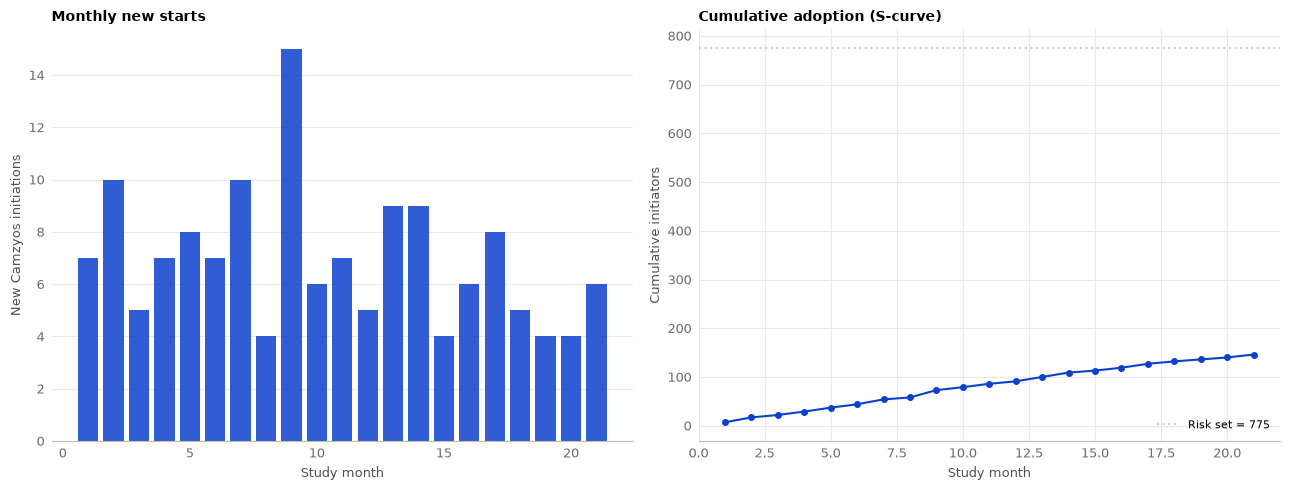


Cumulative penetration: 146/775 = 18.8%


In [8]:
monthly_all = panel.groupby(MONTH_COL)["event"].sum().reset_index()
monthly_all.columns = ["month", "new_starts"]
monthly_all["cumulative"] = monthly_all["new_starts"].cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), facecolor=SURFACE)

ax1.bar(monthly_all["month"], monthly_all["new_starts"], color=C_OBS, alpha=0.85)
ax1.set_xlabel("Study month", fontsize=9, color=INK_SEC)
ax1.set_ylabel("New Camzyos initiations", fontsize=9, color=INK_SEC)
ax1.set_title("Monthly new starts", fontsize=10, fontweight="bold", loc="left")
style_ax(ax1, hide_top_right=True, grid_axis="y")

ax2.plot(monthly_all["month"], monthly_all["cumulative"], marker="o", color=C_OBS, markersize=4)
ax2.axhline(n_patients, color="#C2BAB5", linestyle=":", alpha=0.7, label=f"Risk set = {n_patients}")
ax2.set_xlabel("Study month", fontsize=9, color=INK_SEC)
ax2.set_ylabel("Cumulative initiators", fontsize=9, color=INK_SEC)
ax2.set_title("Cumulative adoption (S-curve)", fontsize=10, fontweight="bold", loc="left")
ax2.legend(fontsize=8, frameon=False)
style_ax(ax2, hide_top_right=True, grid_axis="both")

plt.tight_layout()
plt.show()

penetration = n_events / n_patients
print(f"\nCumulative penetration: {n_events}/{n_patients} = {penetration:.1%}")

## Task 1 — Summary

- **Who:** Treatment escalation history is the strongest predictor. `ccb_ever` (HR 5.40) dominates; age, sex, symptom codes not predictive.
- **When:** Escalated-off-meds archetype has ~2.6%/month hazard (median TTI ~26 months). Unescalated patients effectively never switch.
- **How fast:** Monthly new starts averaged ~10/month in late 2022, decelerated to ~6/month in H2 2023. Cumulative penetration 18.8% in the Diso-eligible pool.
- **Model quality:** AUC 0.72 [0.67, 0.78], BSS +0.009 [+0.004, +0.012], Count MAE 1.7/month [1.5, 3.7].

**Caveat.** The synthetic dataset shows deceleration; BMS quarterly revenue filings show acceleration ($84M Q4 2023 → $201M Q4 2024), suggesting the true trajectory is still accelerating.

---

---

# Part 2 — US Total Addressable Market

**Question:** How many US patients could realistically be prescribed Camzyos?

**Setup.** A transparent top-down epidemiological funnel:

```
TAM = US adults × diagnosed HCM prevalence × Camzyos-eligible fraction
```

Each factor is a triangular distribution over published bounds; Monte Carlo propagates the joint uncertainty. Every parameter carries a citation (Husser 2018 / Butzner 2021 / Massera 2023 for prevalence; Schultze 2022 + Batzner 2019 × Butzner 2026 + Wang 2023 + Charron 2026 for the NYHA II-III eligible share).

Full source: [`src/task2_tam/top_down.py`](../src/task2_tam/top_down.py). Driver + sanity checks: [`scripts/task2_tam/run_task2.py`](../scripts/task2_tam/run_task2.py).

In [9]:
from src.task2_tam.top_down import (
    FunnelParams,
    over_time_from_anchor,
    run_mc,
    variance_decomposition_log,
)

p = FunnelParams()
mc = run_mc(p)
tam = mc["tam"]

median = float(np.percentile(tam, 50))
p10, p90 = float(np.percentile(tam, 10)), float(np.percentile(tam, 90))
print(f"TAM 2026 median: {median / 1000:.0f}k patients")
print(f"80% CI:         [{p10 / 1000:.0f}k, {p90 / 1000:.0f}k]")

vd = variance_decomposition_log(mc["prev"], mc["elig"])
print(
    f"\nLog-variance share: prevalence {vd['prevalence'] * 100:.0f}%  /  eligibility {vd['eligibility'] * 100:.0f}%"
)

over_time = over_time_from_anchor(median, p)
print("\nOver-time projection (from MC median, k patients):")
for scenario_key in ["floor_2pct", "base_4_7pct", "ceiling_7_4pct"]:
    rs = [r for r in over_time if r["scenario"] == scenario_key]
    tail = "  ".join(f"{r['year']}: {r['tam'] / 1000:>3.0f}k" for r in rs)
    print(f"  {scenario_key:<16} ({rs[0]['growth_rate']:.1%}/yr):  {tail}")

TAM 2026 median: 127k patients
80% CI:         [84k, 195k]

Log-variance share: prevalence 58%  /  eligibility 42%

Over-time projection (from MC median, k patients):
  floor_2pct       (2.0%/yr):  2026: 127k  2028: 132k  2030: 137k
  base_4_7pct      (4.7%/yr):  2026: 127k  2028: 139k  2030: 152k
  ceiling_7_4pct   (7.4%/yr):  2026: 127k  2028: 146k  2030: 169k


## 2.2 Results — MC distribution of 2026 TAM

The figure below is pre-generated by [`scripts/task2_tam/run_task2.py`](../scripts/task2_tam/run_task2.py):

- **Distribution** — right-skewed because the prevalence triangle's max (Massera 200/100k) sits well above the mode (Butzner 80/100k).
- **MC median (orange dashed)** — 127k patients.
- **Deterministic mode-product (blue dotted)** — 94k patients, for reference. The MC median is higher because it integrates the long right tail.
- **80% CI band** — 84k – 195k.

![TAM MC distribution](../outputs/task2_tam/02_top_down_tam_2026.png)

Every number is script-asserted against `docs/TASK_1_2_CASE_STUDY.md` (17 exact rounded-k checks).

## Task 2 — Summary

- **US TAM ~127k patients today** (80% CI 84k – 195k), reaching **~137k – 169k by 2030** across growth scenarios (base ~152k).
- **Funnel is source-anchored throughout** — each parameter has a directly cited published bound; the MC integrates the joint uncertainty.
- **Prevalence dominates uncertainty (~58%).** A direct US 2026 prevalence read (IQVIA / Symphony / Komodo against a 30M-life denominator) would collapse most of it.
- **Highest-value additional refinements:** tighten the NYHA II-III symptomatic share via chart review; age-stratify prevalence (<65 vs Medicare); apply a label-strict multiplier for LVEF < 55% and CYP-drug conflicts.

Key limitations: synthetic-data artefacts in Task 1; prevalence triangle uses international/temporal sources; label-strict adjustment not applied (~15–25% overestimate vs strict label). Full limitations in the case study.

---

**End of analysis.** Case study: [`docs/TASK_1_2_CASE_STUDY.md`](../docs/TASK_1_2_CASE_STUDY.md).